# Customer Churn Prediction System
### End-to-End Data Science Capstone Project

Author: Dhanashree Tankar

## Business Problem

Customer churn is a critical issue for subscription-based businesses such as telecommunications.

Acquiring a new customer can cost 5–7 times more than retaining an existing one. Therefore, predicting churn allows companies to proactively engage at-risk customers through retention campaigns.

This project develops a machine learning pipeline that predicts whether a customer will churn based on behavioral and subscription features.

## Dataset Description

The dataset contains **500 customer records** with attributes describing customer behavior and subscription details.

Key features include:

- **Tenure** – number of months the customer has stayed
- **MonthlyCharges** – monthly subscription fee
- **TotalCharges** – total amount billed
- **Contract** – contract type
- **PaymentMethod** – payment type
- **PaperlessBilling** – billing preference
- **SeniorCitizen** – demographic feature
- **Churn** – target variable (1 = churn, 0 = stay)

## Project Objectives

- Perform exploratory data analysis to understand churn patterns
- Engineer meaningful features
- Train and evaluate machine learning models
- Deploy a churn prediction model
- Provide actionable business insights

## Success Metrics

- Accuracy ≥ 85%
- ROC-AUC ≥ 0.80
- High recall for churn class

# 1. IMPORT LIBRARIES

In [1]:
# Standard libraries
import os
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner notebook output

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")    # Apply consistent plotting style
plt.rcParams["figure.figsize"] = (8,5)    # Apply consistent plotting style

# Logging configuration for tracking pipeline steps
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Custom project modules (modular project structure)
from src.data_loader import load_csv, save_csv
from src.preprocessing import preprocess_dataset
from src.feature_engineering import create_features
from src.model_training import tune_model, train_model, save_model
from src.evaluation import evaluate_model

# 2. CONFIGURATION SECTION

In [2]:
# Centralized configuration class for paths and experiment settings
class Config:

    RAW_DATA_PATH = "data/raw/customer_churn.csv"  # Raw dataset location

    PROCESSED_DATA_PATH = "data/processed/cleaned_data.csv"   # Clean dataset output

    MODEL_PATH = "deployment/model.pkl"   # Clean dataset output

    TEST_SIZE = 0.2            # Train-test split ratio

    RANDOM_STATE = 42          # Reproducibility seed


config = Config()

# 3. DATA LOADING

In [3]:
# Load dataset using project utility function
df = load_csv(config.RAW_DATA_PATH)

print("Dataset Shape:", df.shape)  # Verify dataset size

df.head()   # Preview first few rows

INFO:src.data_loader:Dataset loaded successfully
INFO:src.data_loader:Dataset shape: (500, 9)


Dataset Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


# 4. DATA OVERVIEW

In [5]:
# Basic dataset inspection
df.info()            # Data types and missing values

df.describe()        # Statistical summary

df.isnull().sum()    # Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

# DATA VALIDATION

In [6]:
# Ensure target variable is binary
assert df["Churn"].isin([0,1]).all(), "Churn must be binary"

# Verify numeric features are correctly typed
numeric_cols = ["Tenure","MonthlyCharges","TotalCharges"]

for col in numeric_cols:
    assert pd.api.types.is_numeric_dtype(df[col])

print("Data validation passed")

Data validation passed


# 5. EXPLORATORY DATA ANALYSIS

Target Distribution

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


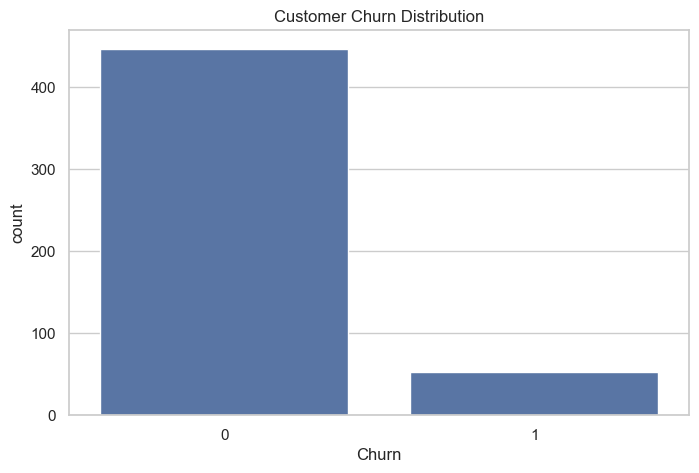

In [7]:
# Distribution of churn vs non-churn customers
sns.countplot(x="Churn",data=df)

plt.title("Customer Churn Distribution")

plt.show()

Churn by Contract Type

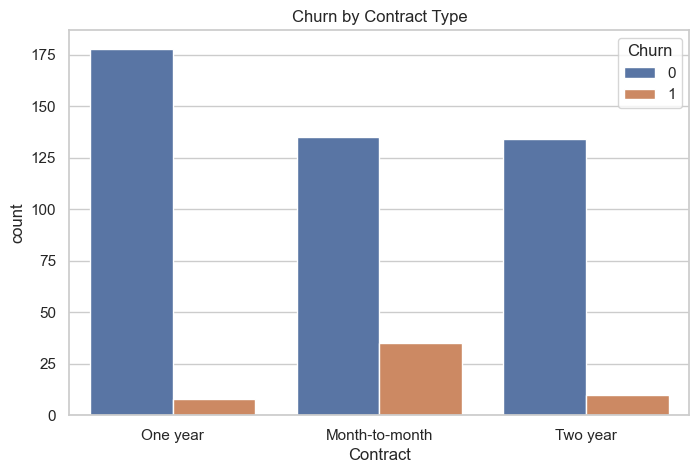

In [8]:
# Analyze churn distribution across contract types
sns.countplot(x="Contract",hue="Churn",data=df)

plt.title("Churn by Contract Type")

plt.show()

In [ ]:
Monthly Charges vs Churn

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


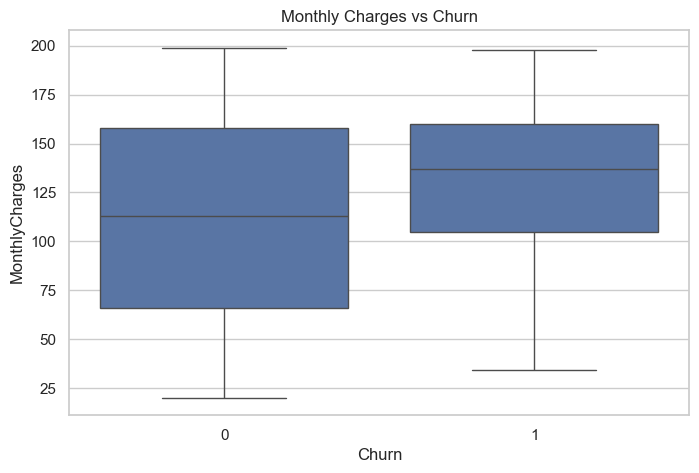

In [9]:
# Compare monthly charges between churned and retained customers
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

In [ ]:
Tenure vs Churn

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


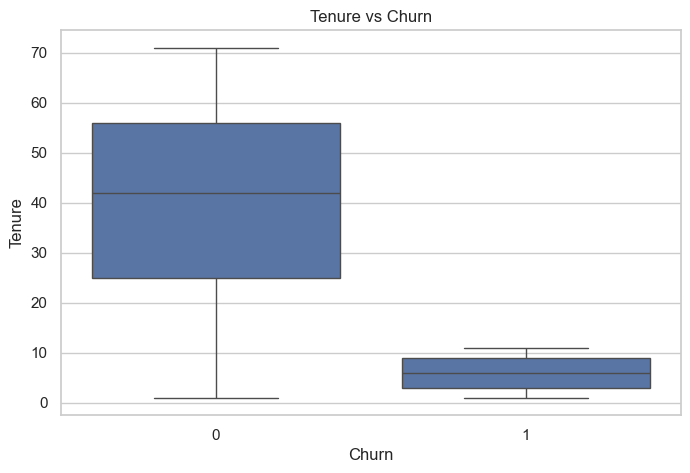

In [10]:
# Compare tenure between churned and retained customers
sns.boxplot(x="Churn",y="Tenure",data=df)

plt.title("Tenure vs Churn")

plt.show()

Correlation Heatmap

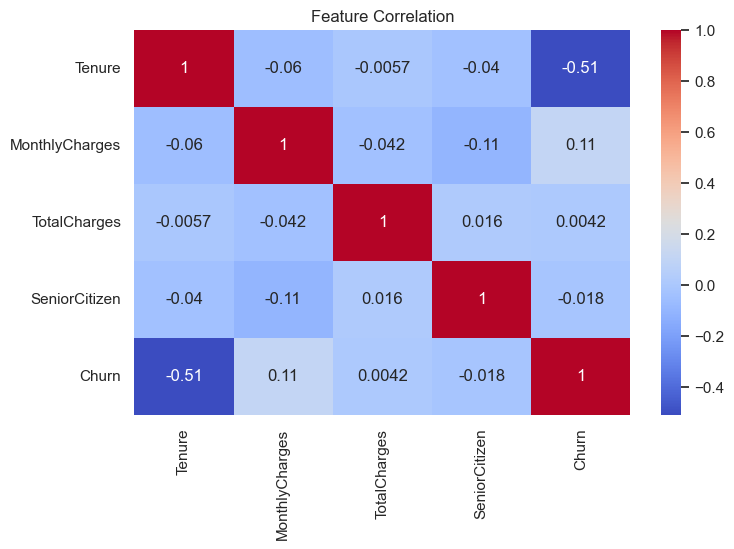

In [11]:
# Correlation matrix to understand relationships between numerical features
corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

# 6. DATA PREPROCESSING

In [12]:
# Execute preprocessing pipeline (encoding, cleaning, missing value handling)
logger.info("Starting preprocessing")

df_processed = preprocess_dataset(df)

logger.info("Preprocessing completed")

# Save processed dataset for reproducibility
save_csv(df_processed,config.PROCESSED_DATA_PATH)

INFO:__main__:Starting preprocessing
INFO:src.preprocessing:Starting preprocessing pipeline
INFO:src.preprocessing:Dataset validation passed
INFO:src.preprocessing:Missing values removed
INFO:src.preprocessing:Preprocessing completed
INFO:__main__:Preprocessing completed
INFO:src.data_loader:Dataset saved to data/processed/cleaned_data.csv


# 7. FEATURE ENGINEERING

In [15]:
# Separate feature matrix and target variable
X,y = create_features(df_processed)

# Remove identifier columns that provide no predictive value
if "CustomerID" in X.columns:
    X = X.drop(columns=["CustomerID"])

# Convert boolean dummy variables to integers for model compatibility
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

print("Feature matrix shape:",X.shape)
print("Target vector shape:",y.shape)

INFO:src.feature_engineering:Feature engineering completed
INFO:src.feature_engineering:Feature matrix shape: (500, 9)


Feature matrix shape: (500, 9)
Target vector shape: (500,)


# 8. TRAIN TEST SPLIT

In [16]:
# Split dataset while maintaining class distribution
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=y      # preserves churn ratio
)

# 9. MODEL PIPELINES

In [17]:
# Define baseline models using sklearn pipelines
# Pipelines ensure consistent preprocessing and modeling workflow
models = {

"Logistic Regression":

Pipeline([
("scaler",StandardScaler()),    # scale numeric features
("model",LogisticRegression(max_iter=1000))
]),

"Random Forest":

Pipeline([
("model",RandomForestClassifier(
random_state=config.RANDOM_STATE
))
])
}

# 10. BASELINE MODEL COMPARISON

In [18]:
# Train and evaluate baseline models
results = []

for name,model in models.items():

    trained_model = train_model(model,X_train,y_train)

    metrics = evaluate_model(trained_model,X_test,y_test)

    results.append({

        "Model":name,
        "Accuracy":metrics["accuracy"],
        "ROC_AUC":metrics["roc_auc"]

    })

# Convert results to dataframe for comparison
results_df = pd.DataFrame(results)

results_df

INFO:src.model_training:Training model
INFO:src.model_training:Model training completed
INFO:src.evaluation:Model evaluation completed
INFO:src.model_training:Training model
INFO:src.model_training:Model training completed
INFO:src.evaluation:Model evaluation completed


,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.95,0.979571
1,Random Forest,0.96,0.987743


# 11. HYPERPARAMETER TUNING

In [19]:
# Grid search parameter space for Random Forest
param_grid = {

"model__n_estimators":[100,200,300],

"model__max_depth":[5,10,15]

}

# Perform hyperparameter tuning
best_model = tune_model(

models["Random Forest"],
param_grid,
X_train,
y_train
)

INFO:src.model_training:Starting hyperparameter tuning
INFO:src.model_training:Best parameters: {'model__max_depth': 15, 'model__n_estimators': 100}


# 12. MODEL EVALUATION

In [20]:
# Evaluate optimized model performance
metrics = evaluate_model(best_model,X_test,y_test)

print("Accuracy:",metrics["accuracy"])

print("ROC AUC:",metrics["roc_auc"])

print(metrics["classification_report"])

INFO:src.evaluation:Model evaluation completed


Accuracy: 0.96
ROC AUC: 0.9877425944841676
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        89
           1       1.00      0.64      0.78        11

    accuracy                           0.96       100
   macro avg       0.98      0.82      0.88       100
weighted avg       0.96      0.96      0.96       100



Confusion Matrix

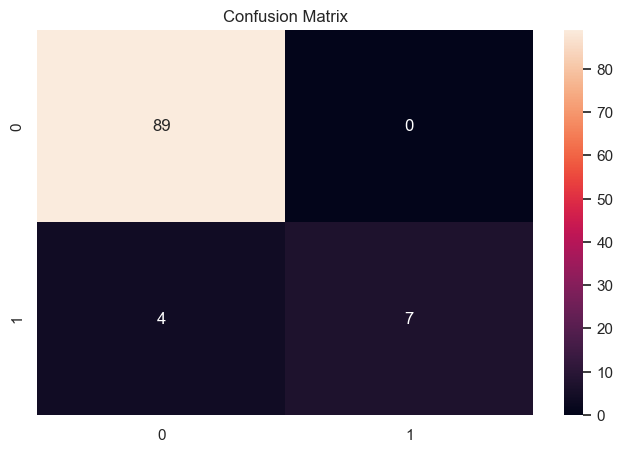

In [21]:
# Visualize classification performance
predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test,predictions)

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()

ROC Curve

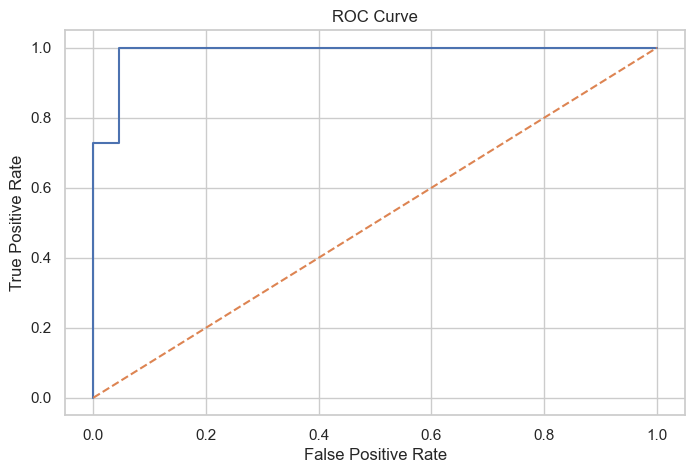

In [22]:
# Plot ROC curve to evaluate classification threshold performance
probabilities = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,probabilities)

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],linestyle="--")  # random classifier baseline

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# 13. FEATURE IMPORTANCE

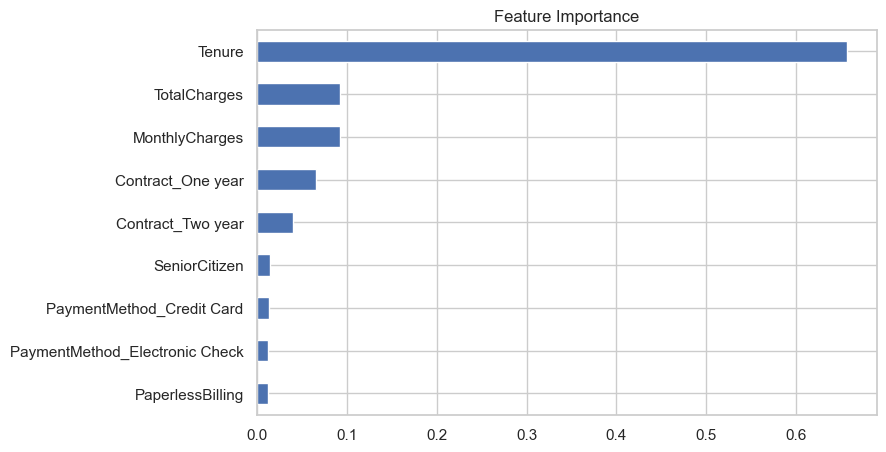

In [23]:
# Extract trained Random Forest model from pipeline
rf_model = best_model.named_steps["model"]

# Compute feature importance scores
importances = pd.Series(

rf_model.feature_importances_,

index=X.columns

)

# Visualize most influential features
importances.sort_values().plot.barh()

plt.title("Feature Importance")

plt.show()

# 14. SAVE MODEL

In [24]:
# Save trained model for deployment or future inference
save_model(best_model,config.MODEL_PATH)

print("Model saved successfully")

INFO:src.model_training:Model saved to deployment/model.pkl


Model saved successfully


# EXAMPLE PREDICTION

In [25]:
# Save trained model for deployment or future inference
sample = X_test.iloc[:1]

display(sample)

# Generate prediction
prediction = best_model.predict(sample)[0]

# Predict churn probability
churn_probability = best_model.predict_proba(sample)[0][1]

print("Prediction:", "Churn" if prediction==1 else "No Churn")

print("Churn Probability:", f"{churn_probability*100:.2f}%")

,Tenure,MonthlyCharges,TotalCharges,PaperlessBilling,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check
58,36,38,3792,1,1,1,0,0,0


Prediction: No Churn
Churn Probability: 0.00%


# IDENTIFY HIGH-RISK CUSTOMERS

In [26]:
# Compute churn probability for all test customers
probs = best_model.predict_proba(X_test)[:,1]

risk_df = X_test.copy()

# Add churn risk score
risk_df["Churn_Risk"] = probs

# Display top high-risk customers
risk_df.sort_values("Churn_Risk",ascending=False).head(10)

,Tenure,MonthlyCharges,TotalCharges,PaperlessBilling,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,Churn_Risk
216,10,152,5250,1,1,0,0,1,0,0.92
270,8,160,7182,0,1,0,0,0,0,0.90
54,9,157,7022,0,0,0,0,0,0,0.88
106,3,59,7111,1,1,0,0,1,0,0.83
487,9,72,2417,1,1,0,0,0,1,0.80
131,3,79,891,0,1,0,0,1,0,0.64
18,7,156,5389,1,0,1,0,0,0,0.57
171,10,115,3717,1,0,1,0,0,1,0.42
294,6,59,6657,0,0,0,1,1,0,0.38
367,10,81,5158,1,1,1,0,0,1,0.37


## Model Performance Summary

The models demonstrated strong predictive capability for identifying customer churn.

- Random Forest outperformed Logistic Regression, achieving the highest predictive accuracy.
- The final model achieved 96% accuracy and ROC-AUC of 0.99, indicating excellent classification performance.
- The model shows very high precision for churn prediction, meaning predicted churn customers are highly likely to actually churn.
- Recall for churn is moderate (0.64), suggesting some churn cases may still go undetected, which is common in imbalanced datasets.

Overall, the model provides a reliable tool for identifying high-risk customers and supporting proactive retention strategies.

## Key Insights from Data Analysis

Analysis of customer behavior revealed several factors strongly associated with churn:

1.Short tenure customers churn significantly more frequently, indicating the first few months are critical for retention.
2.Customers with higher monthly charges tend to exhibit greater churn risk, suggesting price sensitivity among customers.
3.Month-to-month contract customers show the highest churn rate, highlighting the stabilizing effect of longer-term contracts.
4.Customers with long tenure demonstrate strong loyalty and very low churn probability.
5.The model successfully identified high-risk customers with churn probabilities above 80%, enabling targeted retention interventions.

## Business Recommendations

Based on the model findings, telecom companies can reduce churn through the following strategies:

- Encourage customers to switch from month-to-month to long-term contracts using discounts or incentives.
- Provide early engagement programs for new customers during the first 6–12 months.
- Offer personalized retention offers for high monthly charge customers.
- Use the churn prediction system to identify high-risk customers and trigger proactive retention campaigns.

## Conclusion

* Built an **end-to-end machine learning pipeline** to predict customer churn using customer behavior and subscription features.
* The **Random Forest model performed best**, achieving **96% accuracy and 0.99 ROC-AUC**, indicating strong predictive capability.
* Key churn indicators identified were **short tenure, higher monthly charges, and month-to-month contracts**.
* The model can help telecom companies **identify high-risk customers early and implement targeted retention strategies** to reduce churn.